In [22]:
import pandas as pd 
import numpy as np 

import umap 
import pickle as pk

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the Data from Before
We will look at all peptides from all concentrations at all time points. 

In [3]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']

In [4]:
df = data.loc[
            (data.index.get_level_values('CellType') == 'OT-1') & 
            (data.index.get_level_values('Time') >= 0.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
            (data.index.get_level_values('Peptide').isin(ANTIGENS))
         ]

In [5]:
antigen = list(df.index.get_level_values('Peptide'))
time = list(df.index.get_level_values('Time'))

In [6]:
X = np.array(df.values)
y = list(map(lambda x: ANTIGENS.index(x), antigen))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [7]:
standardizer = StandardScaler()
standardizer = standardizer.fit(X_train)

# Now we load the UMAP model that has been trained on this dataset. 
The UMAP was trained using averaged datapoints of group size 20. 

In [8]:
with open("../high_quality_data/full_data_model.pk", 'rb') as file:
    model = pk.load(file)
model

UMAP(min_dist=0.4, n_neighbors=20, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

# Test Embedding Recovery
Now, lets simply transform and untransform the data using the UMAP model to see if we are able to preserve the information from the embedding. 

In [39]:
norm_X_test = standardizer.transform(X_test[:100_000]) # Use a subset for testing purposes. 
norm_X_test.shape

(100000, 26)

In [40]:
embedding = model.transform( norm_X_test )
embedding

array([[ 1.7031071 , 18.136606  ],
       [ 0.31938598,  0.9948485 ],
       [ 8.318872  , -0.4015263 ],
       ...,
       [ 0.28088218,  0.41751206],
       [-6.0346627 ,  0.2907203 ],
       [ 0.79508394, 16.70077   ]], dtype=float32)

In [41]:
recovered_data = model.inverse_transform(embedding)
recovered_data

array([[ 1.5773766 ,  1.4552419 ,  1.8421698 , ...,  1.5234815 ,
         1.1008314 ,  1.1353637 ],
       [-0.9715344 , -0.76180375, -0.63536155, ..., -0.90815634,
        -0.8581955 , -0.88367385],
       [-1.0101416 ,  0.10295307, -0.49280557, ..., -0.6310733 ,
        -0.56127137,  0.68639064],
       ...,
       [-1.1927167 , -0.91732115, -0.594635  , ..., -1.0647645 ,
        -1.0283529 , -0.8672759 ],
       [-1.1641695 , -0.8041735 , -0.76422036, ..., -0.644369  ,
        -0.81034034, -0.96116334],
       [ 2.7732952 ,  1.1958966 ,  2.4185915 , ...,  2.2969575 ,
         1.4753621 ,  0.9604305 ]], dtype=float32)

In [42]:
mse = np.sum((recovered_data - norm_X_test)**2, axis=1)
mse

array([99.86754838,  3.83220316, 12.59076608, ...,  5.20854219,
        3.02119632, 17.0275741 ])

In [43]:
np.mean(mse), np.std(mse)

(15.157153763864892, 23.952119924068846)

### Now we can compare it to the MSE of a standard normal to see if we are even close. 

In [44]:
np.random.seed(42)
random_mse = np.sum((np.random.normal(0,1,norm_X_test.shape) - norm_X_test)**2, axis=1)
random_mse

array([149.33962676,  24.3512021 ,  45.38715091, ...,  26.07612854,
        37.33862489, 129.11673027])

In [45]:
np.mean(random_mse), np.std(random_mse)

(52.00972373810127, 37.762105617608924)

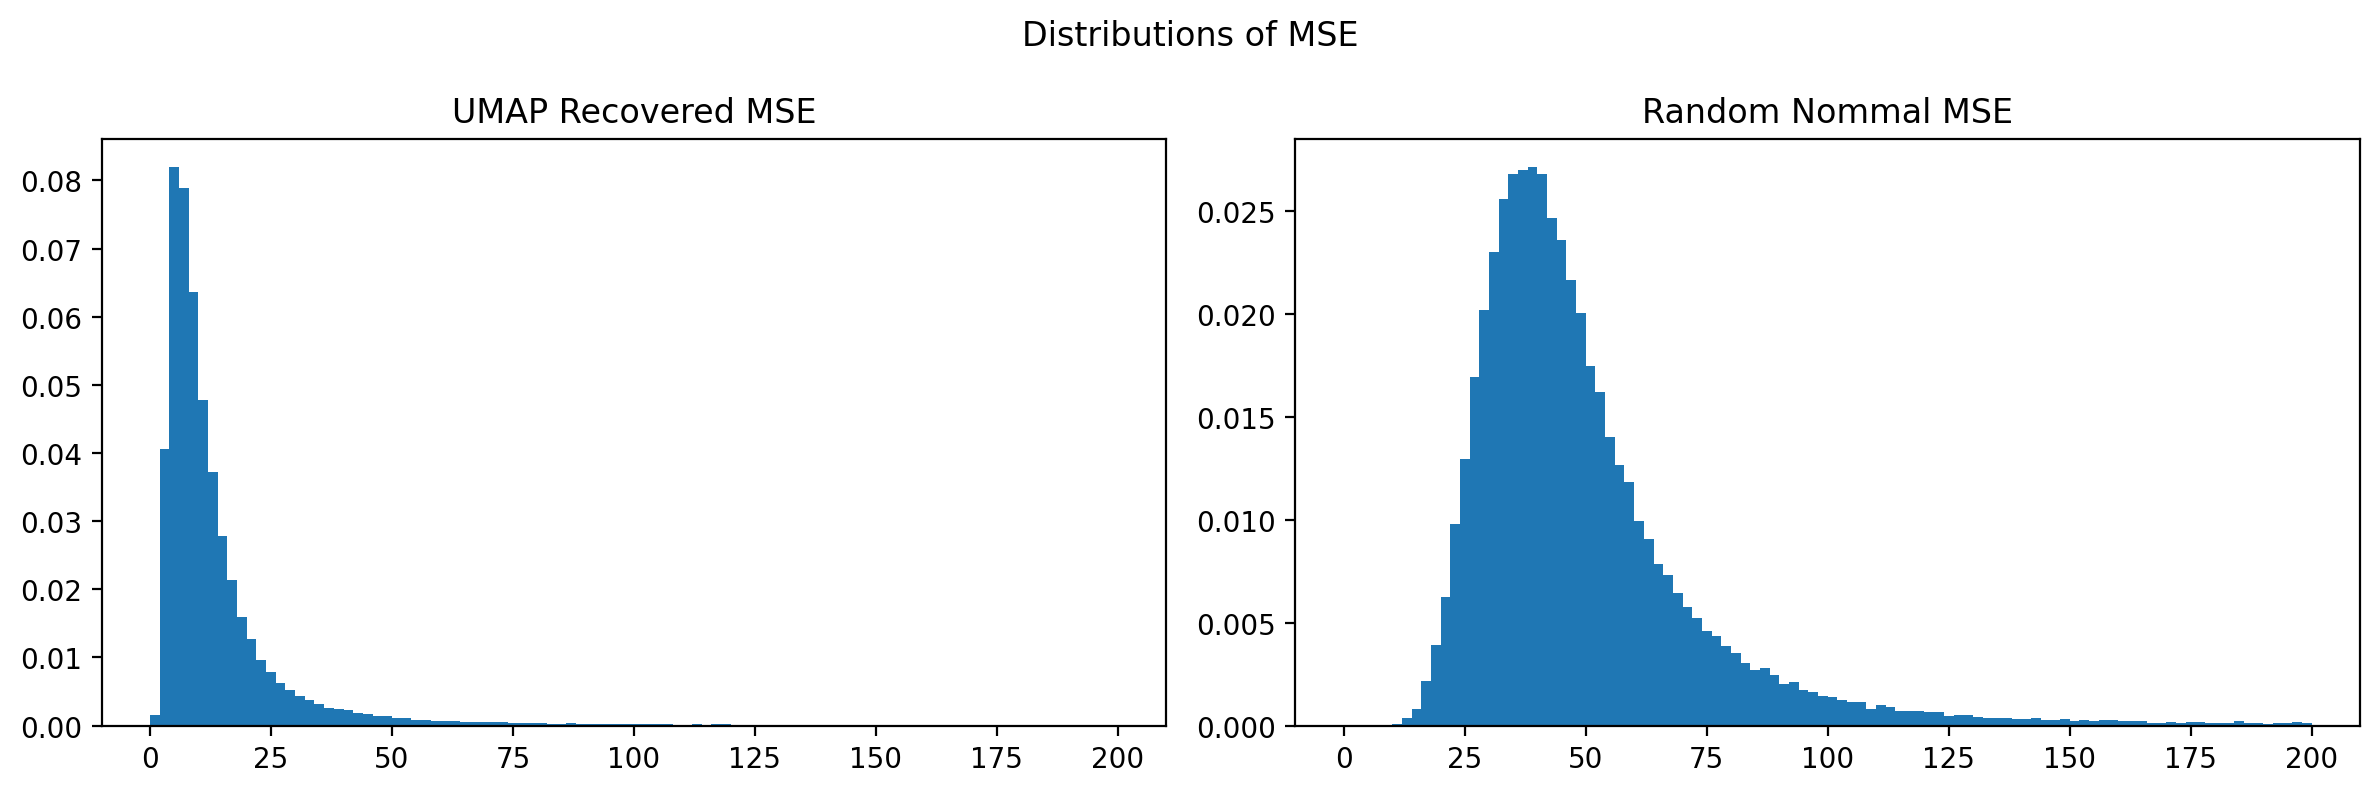

In [86]:
N_BINS = 100
RANGE = (0,200)

fig, ax = plt.subplots(1, 2, figsize=(12,4), dpi=200)

ax[0].hist(mse, bins=N_BINS, range=RANGE, density=True)
ax[0].set_title("UMAP Recovered MSE")

ax[1].hist(random_mse, bins=N_BINS, range=RANGE, density=True)
ax[1].set_title("Random Nommal MSE")

fig.suptitle("Distributions of MSE")

plt.tight_layout()